Citta
Roma       2830.0
Napoli     2760.0
Pavia      2620.5
Milano     2150.2
Genova     1800.5
Torino     1215.0
Bologna     220.0
Name: Consumo_kWh, dtype: float64


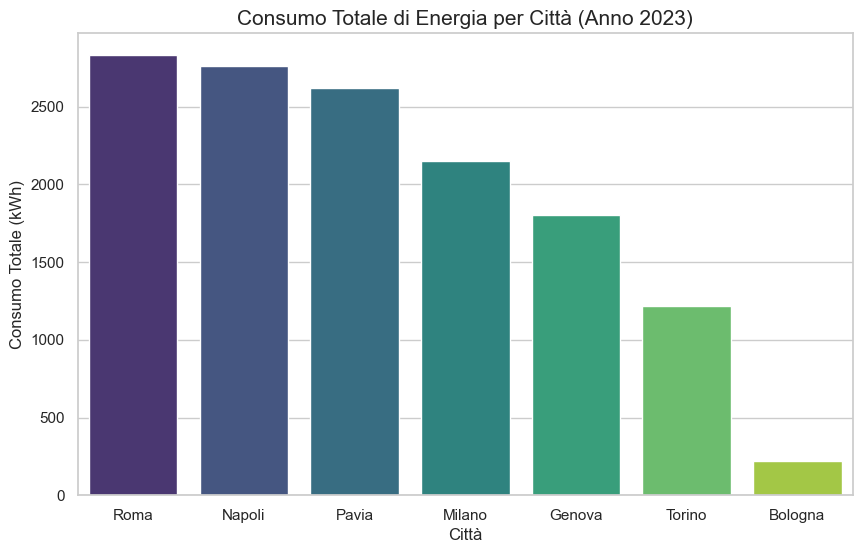

Consumo Medio: 323.29 kWh
Deviazione Standard: 145.42 kWh (Indica quanto variano i prelievi)
Coefficiente di Correlazione con il giorno dell'anno: 0.00


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Caricamento e merge delle tabelle
df_letture=pd.read_csv('letture_energia.csv')
df_anagrafiche=pd.read_csv('anagrafica_cliente.csv')
df_merged=pd.merge(df_letture, df_anagrafiche, on='ID_Contatore', how='outer')

# Pulizia della tabella merged
df_merged['Consumo_kWh']=df_merged['Consumo_kWh'].abs()
df_merged['Data_Lettura']=df_merged['Data_Lettura'].replace('2023-40-10','2023-04-10')
df_merged['Citta']=df_merged['Citta'].str.capitalize() \
                                     .str.replace('Milno','Milano') \
                                     .str.replace('Paviaa','Pavia')

df_merged['Tipo_Tariffa']=df_merged['Tipo_Tariffa'].str.replace('!','',regex=False)

df_merged['Data_Lettura']=pd.to_datetime(df_merged['Data_Lettura'], format='mixed',dayfirst=True)
df_merged=df_merged.drop_duplicates() \
                   .dropna()

# Decido di normalizzare  il dato, sostituisco il typo dopo un confronto utilizando un replace,essendo l'unico valore così alto.
# Scelgo come lettura la media degli altri mesi da me in possesso.

df_merged.loc[df_merged['Consumo_kWh'] > 5000, 'Consumo_kWh'] = 150.0

# Calcolare il consumo totale per ogni città nell'anno 2023
consumo2023=df_merged[df_merged['Data_Lettura'].dt.year==2023] \
                     .groupby('Citta')['Consumo_kWh'].sum() \
                     .sort_values(ascending=False)
print(consumo2023)

# Impostiamo lo stile del grafico
sns.set_theme(style="whitegrid")

# Creiamo la figura
plt.figure(figsize=(10, 6))

# Creiamo un grafico a barre usando i dati di 'consumo2023'
# .index sono le città, .values sono i kWh totali
sns.barplot(
    x=consumo2023.index, 
    y=consumo2023.values, 
    hue=consumo2023.index, # Assegniamo la città al colore (hue)
    palette="viridis", 
    legend=False           # Togliamo la legenda perché i nomi sono già sull'asse X
)

# Aggiungiamo titoli e label
plt.title('Consumo Totale di Energia per Città (Anno 2023)', fontsize=15)
plt.xlabel('Città', fontsize=12)
plt.ylabel('Consumo Totale (kWh)', fontsize=12)

# Salva l'immagine nella stessa cartella del progetto
plt.savefig('output_grafico_consumi.png', dpi=300, bbox_inches='tight')
# Mostriamo il grafico
plt.show()

# Calcoliamo la media e la deviazione standard dei consumi
media_consumi = df_merged['Consumo_kWh'].mean()
deviazione_std = df_merged['Consumo_kWh'].std()

print(f"Consumo Medio: {media_consumi:.2f} kWh")
print(f"Deviazione Standard: {deviazione_std:.2f} kWh (Indica quanto variano i prelievi)")

# Correlazione 
correlazione = df_merged['Consumo_kWh'].corr(df_merged['Data_Lettura'].dt.dayofyear)
print(f"Coefficiente di Correlazione con il giorno dell'anno: {correlazione:.2f}")